In [645]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import binary_fill_holes
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
import math
import pytesseract


#### 0) Lectura de datos

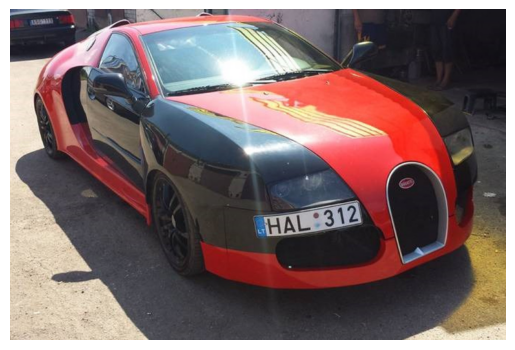

In [646]:
# Cargar la imagen 'auto_1.jpg' con opencv

ruta_imagen = os.path.join("images", "auto_5.jpg")
imagen_bgr = cv2.imread(ruta_imagen)

# Convertir la imagen a formato RGB
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Redimensionar la imagen mediante el método de opencv "resize()" a un tamaño de (768,512)
nuevo_tamano = (768, 512)
imagen_redimensionada = cv2.resize(imagen_rgb, nuevo_tamano)

# Visualizar la imagen
plt.imshow(imagen_redimensionada)
plt.axis('off')  # Ocultar ejes
plt.show()

#### 1) Detección de bordes con Canny

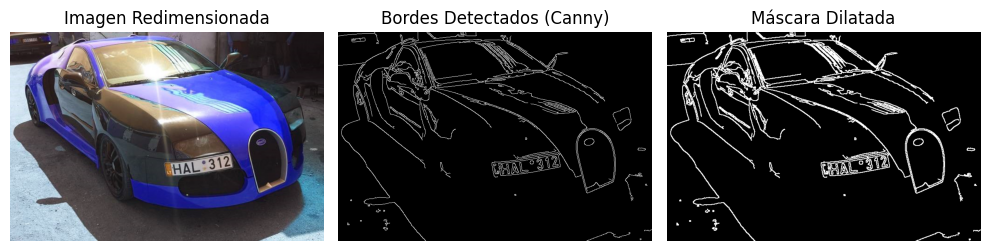

In [647]:
# Aplicar un filtro gaussiano con un kernel de 3x3
kernel_3x3_size = (3, 3)
imagen_filtrada = cv2.GaussianBlur(imagen_redimensionada, kernel_3x3_size, 0)  # sigmaX = 0 permite calcularlo automáticamente

# Aplicar el método de Canny para la detección de bordes
imagen_gris = cv2.cvtColor(imagen_filtrada, cv2.COLOR_BGR2GRAY)

"""  
Tras varias pruebas los siguientes umbrales funcionan para las 5 imágenes
"""
umbral_max = 255  
umbral_min = 55   

bordes = cv2.Canny(imagen_gris, umbral_min, umbral_max)


# Aplicar una dilatación con un kernel de 2x2 y 1 iteración
kernel_2x2 = np.ones((2, 2), np.uint8)
imagen_dilatada = cv2.dilate(bordes, kernel_2x2, iterations=1)


# Visualizar la máscara resultante
plt.figure(figsize=(10, 7))

# Mostrar la imagen original redimensionada
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(imagen_redimensionada, cv2.COLOR_BGR2RGB))
plt.title("Imagen Redimensionada")
plt.axis("off")

# Mostrar los bordes detectados
plt.subplot(1, 3, 2)
plt.imshow(bordes, cmap='gray')
plt.title("Bordes Detectados (Canny)")
plt.axis("off")

# Mostrar la máscara dilatada (máscara resultante)
plt.subplot(1, 3, 3)
plt.imshow(imagen_dilatada, cmap='gray')
plt.title("Máscara Dilatada")
plt.axis("off")

plt.tight_layout()
plt.show()

#### 2) Procesamiento mediante operaciones morfológicas

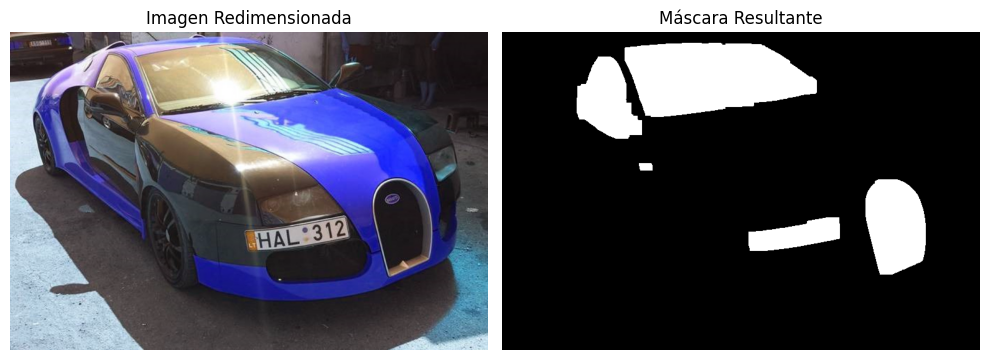

In [648]:
# Aplicar el comando "binary_fill_holes" sobre los bordes detectados.
# Nota: convertir la imagen a formato "uint8"
bordes_rellenos = binary_fill_holes(imagen_dilatada > 0).astype(np.uint8)



# Aplicar una apertura en el eje vertical con un kernel de 20x1 y 1 iteración para eliminar bordes verticales. 
# Nota: Aplicar el método de opencv "mophologyEx()" con cv2.MORPH_OPEN. 
kernel_vertical = np.ones((20, 1), np.uint8)
apertura_vertical = cv2.morphologyEx(bordes_rellenos, cv2.MORPH_OPEN, kernel_vertical, iterations=1)

# Aplicar una apertura en el eje horizontal con un kernel de 1x20 y 1 iteración para eliminar bordes horizontales
kernel_horizontal = np.ones((1, 20), np.uint8)
apertura_horizontal = cv2.morphologyEx(apertura_vertical, cv2.MORPH_OPEN, kernel_horizontal, iterations=1)


# Eliminar artefactos, es decir, objetos cuya área tenga menos de 1000 píxeles con una connectivity=8.  
# Nota: utilizar el método "remove_small_objects()" sobre la máscara anterior en formato booleano. 
mascara_booleano = np.array(apertura_horizontal, bool)
mascara_limpia = remove_small_objects(mascara_booleano, min_size=100, connectivity=8)

# Convertir la máscara resultante a formato uint8
mascara_resultante = (mascara_limpia * 255).astype(np.uint8)



# Visualizar la máscara resultante
plt.figure(figsize=(10, 7))

# Mostrar la imagen original redimensionada
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen_redimensionada, cv2.COLOR_BGR2RGB))
plt.title("Imagen Redimensionada")
plt.axis("off")

# Mostrar la máscara resultante
plt.subplot(1, 2, 2)
plt.imshow(mascara_resultante, cmap='gray')
plt.title("Máscara Resultante")
plt.axis("off")

plt.tight_layout()
plt.show()

#### 3) Detección automática de la región de interés correspondiente a la matrícula

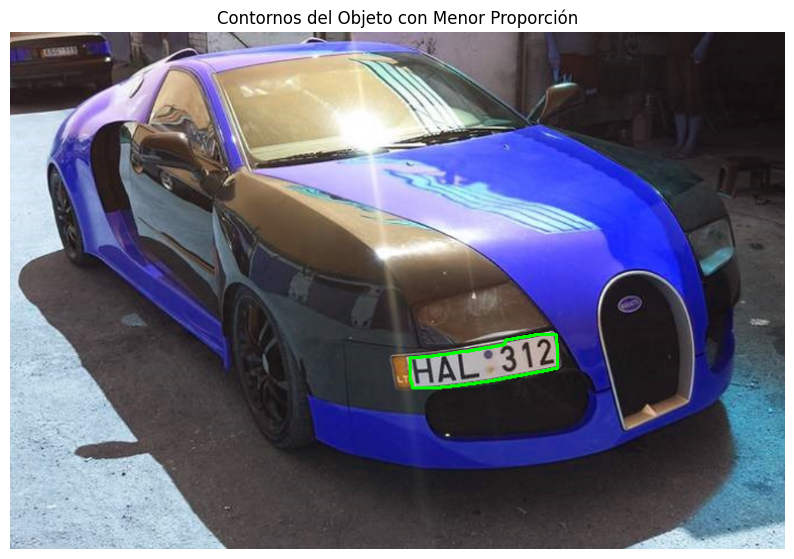

In [649]:
# Crear una imagen de etiquetas mediante el comando "label"
etiquetas = label(mascara_limpia)


# Calcular la proporción (cociente) entre el minor_axis_length y el major_axis_length para cada objeto de la imagen de etiquetas
proporciones = []
for region in regionprops(etiquetas):
    minor_axis = region.minor_axis_length
    major_axis = region.major_axis_length
    proporciones.append(minor_axis / major_axis)


# Generar una máscara que contenga únicamente el objeto de la menor proporción. 
indice_menor_proporcion = np.argmin(proporciones)
mascara_menor_proporcion = np.zeros_like(mascara_limpia, dtype=bool)

for region in regionprops(etiquetas):
    if region.label == indice_menor_proporcion + 1:  # Las etiquetas comienzan desde 1
        mascara_menor_proporcion[region.coords[:, 0], region.coords[:, 1]] = 1


# Dibujar los contornos de la máscara sobre la imagen original y visualizar el resultado

contornos, _ = cv2.findContours(mascara_menor_proporcion.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
imagen_con_contornos = imagen_redimensionada.copy()

# Dibujar los contornos en la imagen original
cv2.drawContours(imagen_con_contornos, contornos, -1, (0, 255, 0), 2)  # Color verde, grosor 2

# Visualizar el resultado
plt.figure(figsize=(10, 7))

plt.imshow(cv2.cvtColor(imagen_con_contornos, cv2.COLOR_BGR2RGB))
plt.title("Contornos del Objeto con Menor Proporción")
plt.axis("off")
plt.show()

#### 4) Procesamiento de la región de interés

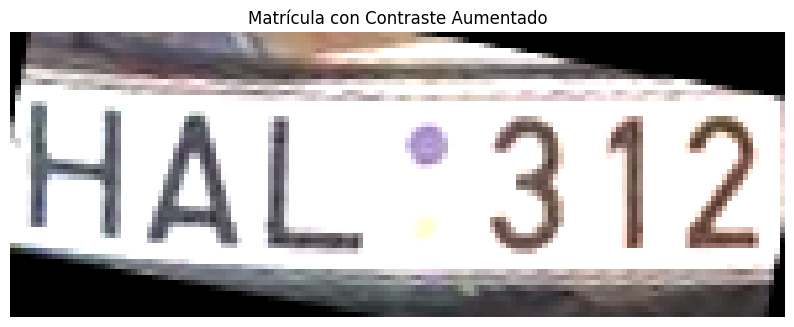

In [650]:
# Calcular la boundingbox de la máscara

etiquetas = label(mascara_limpia)  

for region in regionprops(etiquetas):
    if region.label == indice_menor_proporcion + 1:  
        min_row, min_col, max_row, max_col = region.bbox
        break


# Hacer un crop de la imagen original a partir de las coordenadas de la boundingbox
crop_imagen = imagen_redimensionada[min_row:max_row, min_col:max_col]

# Calcular la orientación de la máscara. 
orientation = region.orientation 


# Hacer una conversión mediante la siguiente fórmula:
    # angle = (orientation*90)/(math.pi/2). Nota: utilizar "import math"
    # Si 'angle' es mayor que 0, la orientación será igual a 90-angle
    # Si no, la orientación será igual a -(90+angle)
angle = (orientation * 90) / (math.pi / 2)
if angle > 0:
    angle = 90 - angle
else:
    angle = -(90 + angle)



# Aplicar una transformación geométrica de rotación para orientar horizontalmente el crop de la imagen obtenido anteriormente
center = (crop_imagen.shape[1] // 2, crop_imagen.shape[0] // 2) # Definir el centro de la imagen para la rotación
rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_crop = cv2.warpAffine(crop_imagen, rotation_matrix, (crop_imagen.shape[1], crop_imagen.shape[0]))


# Aumentar el contraste 100 unidades de acuerdo a la fórmula vista en clase. 
contraste = 100
brillo = 0
rotated_contrast = cv2.convertScaleAbs(rotated_crop, alpha=1 + contraste / 100, beta=brillo)


# Visualizar el resultado la matrícula con el contraste aumentado

plt.figure(figsize=(10, 7))

plt.imshow(cv2.cvtColor(rotated_contrast, cv2.COLOR_BGR2RGB))
plt.title("Matrícula con Contraste Aumentado")
plt.axis("off")
plt.show()


#### 5) Convertir el contenido de la imagen en un string mediante la librería 'pytesseract'
Para instalar la librería pytesseract:
    
    Descargar el ejecutable en -->  https://github.com/UB-Mannheim/tesseract/wiki
    Instalar la librería haciendo --> pip install pytesseract

Si se tienen dudas, consultar el siguiente vídeo:

    https://www.youtube.com/watch?v=_j6o2rBkhhg

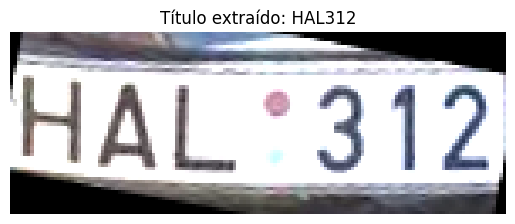

In [651]:
# Crear la ruta de pytesseract que contenga el ejecutable
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract'

# Convertir el contenido de la imagen en una variable de tipo string.
# Importante: utiliza la opción --> config='--psm 10'
string = pytesseract.image_to_string(rotated_contrast, config='--psm 10')


# Eliminar del string los caracteres especiales mediante la siguiente línea de código:
# string = ''.join(filter(str.isalnum, string))
string = ''.join(filter(str.isalnum, string))

# Visualizar la imagen original y ponle el título extraído automáticamente mediante la librería "pytesseract"
plt.imshow(rotated_contrast)
plt.title(f'Título extraído: {string}')
plt.axis('off') 
plt.show()